In [46]:
import numpy as np
import matplotlib.pyplot as plt
import ultranest
import ultranest.stepsampler
import h5py
from ultranest.plot import cornerplot

In [47]:
from src.noise import add_noise_snr
from src.config import Config
from src.simulation import Simulation
from src.utilities import estimate_neff
from src.builders import build_problem
from sampling.posterior import FWIPosterior
from src.layers import create_layers_from_interfaces
from src.plot.plot_tools import plot_seismogram, set_plot_style
set_plot_style()

In [48]:
seed = 42
rng = np.random.default_rng(seed)

In [49]:
config = Config(n_receivers=8, x_min=600., x_max=2000.,
                   z_rec=50., z_src=20., x_src=50., nq_prop=128, f0=5.,
                   total_time=1.5, delay=0.15, epsilon=1.5, free_surface=False, nfft_pad_factor=1)
param, acq = build_problem(config)
dxr = acq.xr[1] - acq.xr[0]
dt = param.dt
print(dt)
print(len(param.time))

0.0125
121


In [50]:
vps = np.array([1500.0, 1800.0, 3200.0]) # 1800, 3200, or 2200, 3000
vp_ref = np.array([vps[1], vps[2]])
z_int = np.array([0.0, 100., 250., 400.])
rhos = np.array([2000.0, 2000.0, 2000.0])
layers = create_layers_from_interfaces(z_int, vps, rhos)

In [51]:
sim = Simulation(config)
d_obs, _ = sim.forward(layers)
d_obs_noise, std_noise = add_noise_snr(d_obs, snr_db=20, seed=seed)
print(std_noise)

0.037287556151975404


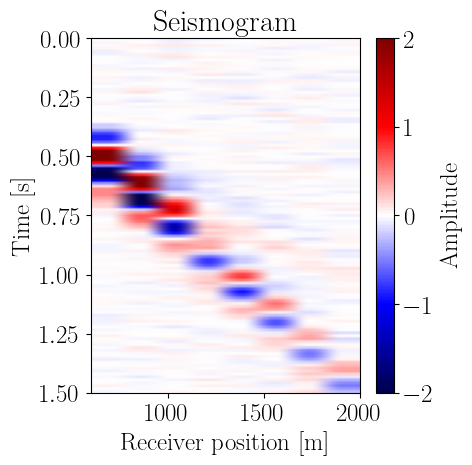

In [52]:
plot_seismogram(d_obs_noise.T, sim.acq.xr, sim.param.time, vmin=-2, vmax=2, ncolors=256, figsize=(5,5))

In [53]:
# prior mean and covariance for the velocities
mu = np.array([2500.0, 2500.0])
cov = np.diag([500**2, 500**2])
result = estimate_neff(d_obs[0])
beta = 0.1 / d_obs_noise.size # result["n_eff"] / d_obs_noise.size
print(beta)
print(d_obs_noise.size)
# Initialize the posterior object
bayes = FWIPosterior(
    d_obs_noise,
    layers,
    sim,
    mu,
    cov,
    std_noise=float(std_noise),
    beta=beta, # normalize by the number of data points
    scale_factor=1.
)

0.00010330578512396695
968


In [54]:
from scipy.stats import truncnorm
def prior_transform(cube):
    """
    Maps UltraNest's [0, 1] unit cube to Gaussian priors for the layer velocities, truncated to a reasonable range.
    """
    # Bounds for Vp
    v_min, v_max = 800.0, 4000.0
    mu = bayes.mu
    sigma = np.sqrt(np.diag(bayes.cov))
    a_scaled = (v_min - mu) / sigma
    b_scaled = (v_max - mu) / sigma
    # Map the entire cube in one shot
    return truncnorm.ppf(cube, a_scaled, b_scaled, loc=mu, scale=sigma)

def log_likelihood(params):
    return bayes.log_likelihood(params)


In [55]:
from src.utilities import timer
def run_diagnostic_checks(prior_transform, v_true=None):
    """
    Performs sanity checks on the Likelihood, Prior, and Parameter Mapping.
    """
    mu = bayes.mu
    sigma = np.sqrt(np.diag(bayes.cov))

    print("\n" + "=" * 50)
    print(f"{'BAYESIAN FWI DIAGNOSTIC CHECKS':^50}")
    print("=" * 50)

    # 1. Check at Prior Mean
    with timer("prior eval"):
        lp_mu = bayes.log_prior(mu)
    with timer("likelihood eval"):
        ll_mu = bayes.log_likelihood(mu)
    print(f"[*] Prior Mean (mu): {mu}")
    print(f"    > log_prior:      {lp_mu:.4f}")
    print(f"    > log_likelihood: {ll_mu:.4f}")

    # 2. Check at mu + sigma (Sensitivity Check)
    vp_test = mu + sigma
    with timer("likelihood eval"):
        ll_sigma = bayes.log_likelihood(vp_test)
    delta_ll = ll_sigma - ll_mu
    print(f"[*] Shifted (mu + sigma): {vp_test}")
    print(f"    > log_likelihood: {ll_sigma:.4f}")
    print(f"    > Delta LL:       {delta_ll:.4f}")

    # 3. Reference Check (The 'Target' Score)
    if v_true is not None:
        with timer("likelihood eval"):
            ll_ref = bayes.log_likelihood(v_true)
        print(f"[*] True Reference:      {v_true}")
        print(f"    > log_likelihood: {ll_ref:.4f}")
        print(f"    > Distance to Target: {ll_ref - ll_mu:.4f} (log-units)")

    # 4. Range & Sensitivity Validation
    if np.isclose(ll_mu, ll_sigma, rtol=1e-5):
        print("\n!! WARNING: Likelihood is FLAT. The data is not sensitive to Vp.")
        print("   Check if noise_std is too large or if the simulation is running.")

    if np.abs(delta_ll) > 1e6:
        print("\n!! WARNING: Likelihood is extremely SHARP.")
        print(
            "   This might lead to poor sampling. Consider increasing noise_std or beta."
        )

    # 5. Prior Transform Mapping (Unit Cube -> Physical)
    test_cube = np.array([0.5] * len(mu))
    transformed = prior_transform(test_cube)
    print("\n[*] Prior Mapping Check:")
    print(f"    > Unit Cube [0.5] maps to: {transformed}")

    # Check if mapping stays in bounds
    if np.any(transformed < 1000) or np.any(transformed > 7000):
        print("    !! ERROR: Prior transform is mapping outside [1000, 7000]!")
    else:
        print("    > Range check: PASS")

    print("=" * 50 + "\n")

print(std_noise)
run_diagnostic_checks(prior_transform, vp_ref)

0.037287556151975404

          BAYESIAN FWI DIAGNOSTIC CHECKS          
prior eval elapsed: 0.00 s
likelihood eval elapsed: 0.08 s
[*] Prior Mean (mu): [2500. 2500.]
    > log_prior:      -14.2671
    > log_likelihood: -2.0755
likelihood eval elapsed: 0.07 s
[*] Shifted (mu + sigma): [3000. 3000.]
    > log_likelihood: -2.3543
    > Delta LL:       -0.2788
likelihood eval elapsed: 0.06 s
[*] True Reference:      [1800. 3200.]
    > log_likelihood: 0.1876
    > Distance to Target: 2.2631 (log-units)

[*] Prior Mapping Check:
    > Unit Cube [0.5] maps to: [2499.36521579 2499.36521579]
    > Range check: PASS



In [68]:
param_names = [f"Vp_{i+1}" for i in range(len(vps[1:]))]

sampler = ultranest.ReactiveNestedSampler(
    param_names,
    log_likelihood,
    prior_transform,
    log_dir = "ultranest_run3",
    resume  = "resume",
)

In [57]:
#sampler.stepsampler = ultranest.stepsampler.SliceSampler(
#    nsteps             = 4 * len(vps[1:]),
#    generate_direction = ultranest.stepsampler.generate_mixture_random_direction
#)

In [70]:
result = sampler.run(
    min_num_live_points          = 800,    # ≥ 400 recommended; raise to 800 for 10-D
    dlogz                        = 0.5,    # log-evidence accuracy; 0.5 is standard
    min_ess                      = 2000,   # effective samples; raise to 5000 if budget allows
    update_interval_volume_fraction = 0.4, # how often to rebuild the sampling region
    max_num_improvement_loops    = 5,      # refinement passes over the posterior tail
)

[ultranest] Resuming from 2579 stored points
[ultranest] Sampling 800 live points from prior ...


[ultranest] Explored until L=0.2  0.1596..0.1597]*| it/evals=5165/9222 eff=137.4767% N=800 00 
[ultranest] Likelihood function evaluations: 9223
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -1.685 +- 0.01858
[ultranest] Effective samples strategy satisfied (ESS = 3387.1, need >2000)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.02, need <0.5)
[ultranest]   logZ error budget: single: 0.02 bs:0.02 tail:0.01 total:0.02 required:<0.50
[ultranest] done iterating.


In [71]:
#result = sampler.run(min_ess=2000, min_num_live_points=400)
#sampler.print_results()

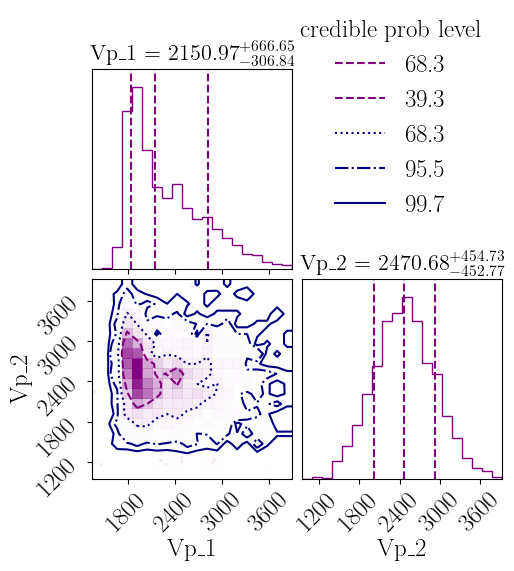

In [72]:
figure = cornerplot(result, plot_density=True, title_kwargs={"fontsize": 16}, plot_datapoints=True)
plt.show()

In [74]:
samples = result["samples"]          # shape (N_eff, D) — already equal-weighted
weights = result["weighted_samples"]["weights"]   # for diagnostics / re-weighting

print(f"\nEqual-weighted posterior samples: {samples.shape}")
print(f"Effective sample size (ESS): {result['ess']:.0f}")
print(f"log Z = {result['logz']:.3f} ± {result['logzerr']:.3f}")

# Save for comparison experiments
np.save("ultranest_run2/results/reference_samples.npy", samples)
print("Saved → ultranest_run2/results/reference_samples.npy")


# ── 8.  DIAGNOSTICS ───────────────────────────────────────────────────────────
#
# Always inspect these before trusting the reference:
#
#   trace plot  – each parameter's explored range should shrink smoothly.
#                 Jumps or plateaus indicate poor mixing → increase nsteps.
#   corner plot – marginals and correlations; compare to your SVGD / VI output.
#   run plot    – logZ and live-point count over iterations.

sampler.plot_run()       # saved to ultranest_run/plots/run.pdf
sampler.plot_trace()     # saved to ultranest_run/plots/trace.pdf
sampler.plot_corner()    # saved to ultranest_run/plots/corner.pdf


Equal-weighted posterior samples: (5967, 2)
Effective sample size (ESS): 3387
log Z = -1.679 ± 0.025
Saved → ultranest_run2/results/reference_samples.npy


In [75]:
from ultranest.plot import PredictionBand
band2 = PredictionBand(sim.param.time)
band4 = PredictionBand(sim.param.time)
band7 = PredictionBand(sim.param.time)
ns = len(sampler.results['samples'])
# go through the solutions
for vp1, vp2 in sampler.results['samples'][0:ns:10]:
    # compute for each time the y value
    VP = np.array([vps[0], vp1, vp2])
    lays = create_layers_from_interfaces(z_int, VP, rhos)
    d_cal = sim.forward(lays)[0]
    band2.add(d_cal[0, 2, :])
    band4.add(d_cal[0, 4, :])
    band7.add(d_cal[0, 7, :])

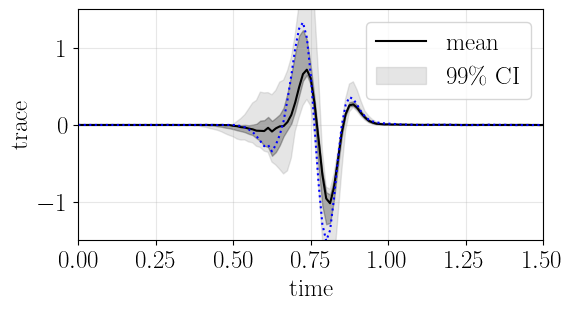

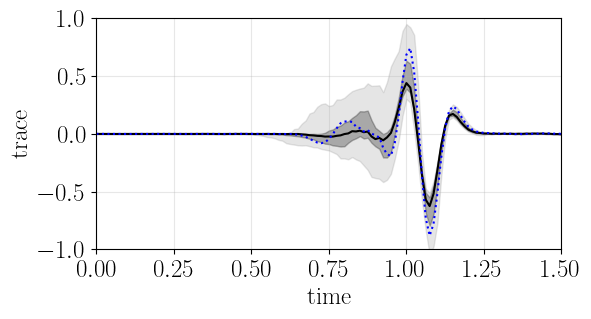

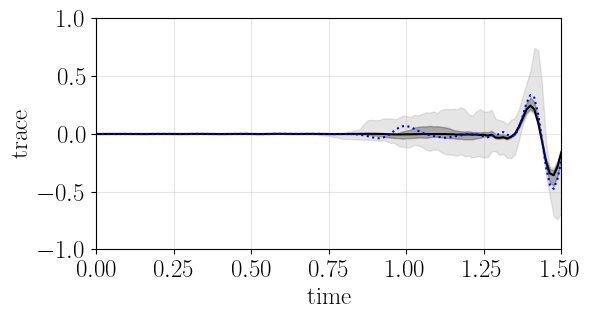

In [76]:
d_ref = d_obs.squeeze()
# plot prediction bands for trace 1
plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band2.line(color='k', label='mean')
band2.shade(color='k', alpha=0.3)
band2.shade(q=0.495, color='gray', alpha=0.2, label='99\% CI')
plt.plot(sim.param.time, d_ref[2], 'b:')
plt.ylim([-1.5,1.5])
plt.xlim([0.0, sim.param.time[-1]])
plt.grid(alpha=0.3)
plt.legend()

# plot prediction bands for trace 4
plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band4.line(color='k')
band4.shade(color='k', alpha=0.3)
band4.shade(q=0.495, color='gray', alpha=0.2)
plt.plot(sim.param.time, d_ref[4], 'b:')
plt.ylim([-1.,1.])
plt.xlim([0.0, sim.param.time[-1]])
plt.grid(alpha=0.3)

# plot prediction bands for trace 15
plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band7.line(color='k')
band7.shade(color='k', alpha=0.3)
band7.shade(q=0.495, color='gray', alpha=0.2)
plt.plot(sim.param.time, d_ref[7], 'b:')
plt.ylim([-1.,1.])
plt.xlim([0.0, sim.param.time[-1]])
plt.grid(alpha=0.3)